In [30]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
import math

In [3]:
movie_data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
movie_data.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [4]:
print("number of passengers in original data:" +str(len(movie_data.index)))

number of passengers in original data:15509


ANALYSIS OF DATA

<Axes: xlabel='Year', ylabel='count'>

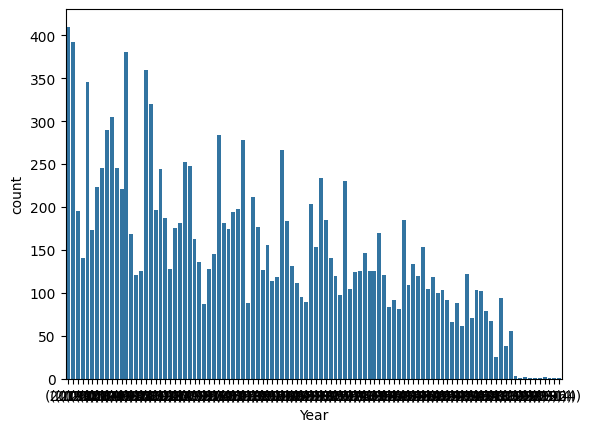

In [5]:
sns.countplot(x="Year", data=movie_data)

In [6]:
print(movie_data.shape)

(15509, 10)


In [7]:
print(movie_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [8]:
print(movie_data.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [9]:
print(movie_data.describe())

            Rating
count  7919.000000
mean      5.841621
std       1.381777
min       1.100000
25%       4.900000
50%       6.000000
75%       6.800000
max      10.000000


DATA CLEANING

In [10]:
movie_data.dropna(inplace=True)

<Axes: >

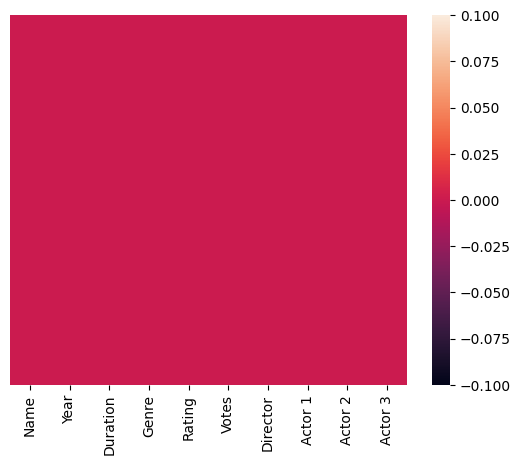

In [11]:
sns.heatmap(movie_data.isnull(), yticklabels=False)

In [13]:
movie_data.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

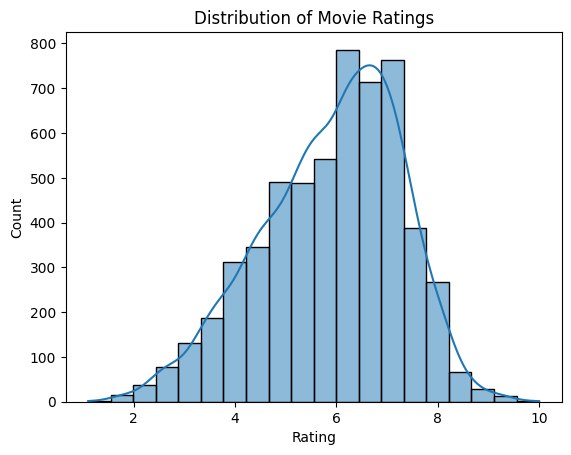

In [14]:
sns.histplot(movie_data['Rating'], bins=20, kde=True)

plt.title("Distribution of Movie Ratings")

plt.xlabel("Rating")

plt.show()

<Axes: xlabel='Genre'>

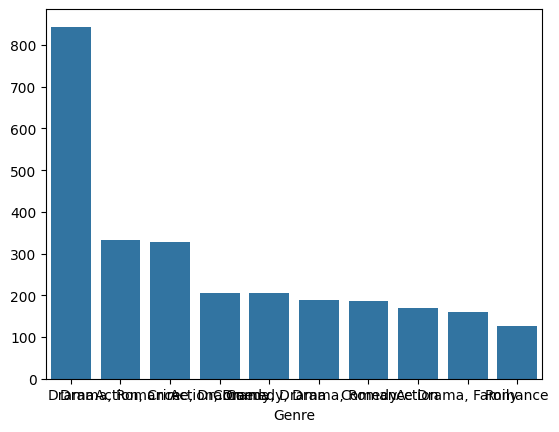

In [15]:
top_genres = movie_data['Genre'].value_counts().head(10)

sns.barplot(
    x=top_genres.index,
    y=top_genres.values
)

<Axes: xlabel='Director'>

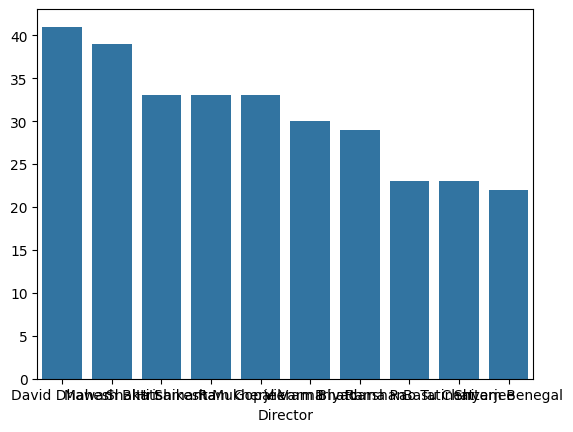

In [16]:
top_directors = movie_data['Director'].value_counts().head(10)

sns.barplot(
    x=top_directors.index,
    y=top_directors.values
)

In [17]:
movie_data['Votes'] = movie_data['Votes'].astype(str)

movie_data['Votes'] = movie_data['Votes'].str.replace(',', '')

movie_data['Votes'] = pd.to_numeric(movie_data['Votes'], errors='coerce')


In [18]:
movie_data['Duration'] = movie_data['Duration'].astype(str)

movie_data['Duration'] = movie_data['Duration'].str.replace(' min', '')

movie_data['Duration'] = pd.to_numeric(movie_data['Duration'], errors='coerce')

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [21]:
encoder = LabelEncoder()

movie_data['Genre'] = encoder.fit_transform(movie_data['Genre'])

movie_data['Director'] = encoder.fit_transform(movie_data['Director'])

movie_data['Actor 1'] = encoder.fit_transform(movie_data['Actor 1'])

movie_data['Actor 2'] = encoder.fit_transform(movie_data['Actor 2'])

movie_data['Actor 3'] = encoder.fit_transform(movie_data['Actor 3'])

TRAIN MODEL

In [22]:
X = movie_data[[
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3',
    'Votes',
    'Duration'
]]

y = movie_data['Rating']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
predictions = model.predict(X_test)

In [27]:
mean = mean_absolute_error(y_test, predictions)
print(mean)

1.0897063810138978


In [28]:
mean_s = mean_squared_error(y_test, predictions)
print(mean_s)

1.7740498999139709


In [32]:
rmse = np.sqrt(mean_s)
print(rmse)

1.3319346455115473


In [33]:
r2 = r2_score(y_test, predictions)
print(r2)

0.04195707455485698


In [34]:
results = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': predictions
})

print(results.head(10))

       Actual Rating  Predicted Rating
10971            6.0          5.599488
14052            2.4          5.984765
10002            3.8          5.879129
3970             3.8          5.689435
8840             7.2          5.601433
5071             6.3          5.807462
2709             8.6          5.772567
11842            3.9          6.371932
10910            6.6          5.892810
4485             6.6          5.986466
